In [56]:
import osmnx as ox, networkx as nx
import numpy as np, scipy.sparse as sp, scipy.sparse.linalg as spla
from sklearn.cluster import KMeans
import scipy
import matplotlib.pyplot as plt

In [57]:
# ——— globals ———
K_CLUSTERS  = 15          # number of clusters in the map
SHIFT       = 1e-3       # μ for inverse power method 
IP_MAXITER  = 500        # iteration threshold
IP_TOL      = 1e-6       # maximum tolerance

MultiGraph with 598 nodes and 869 edges


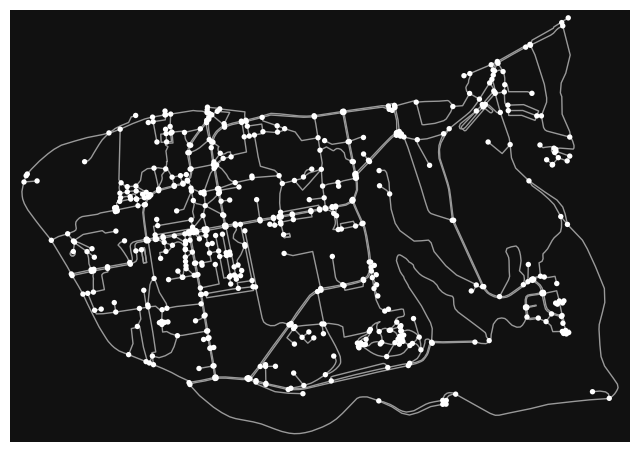

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [58]:
# Fetchs using osmnx, makes it undirected then prints
place_name =  'Istanbul Teknik Universitesi , Sariyer , Istanbul , Turkey'
G_roadmap = ox.graph_from_place(place_name, network_type='walk')
G = G_roadmap.to_undirected()
print(G)
ox.plot_graph(G)

In [59]:
#Various laplacian calculations corresponding to different weighted adjacency matrices
def laplacian_unweighted(A): # W is formed directly using the adjacency matrix A, W = A
    return np.diag(A.sum(1)) - A

def laplacian_avglen(G): # W is formed using with this formula: wij = wji = (average edge length / current edge length) 
    idx = {n:i for i,n in enumerate(G)}
    n   = len(G)
    lens = [d.get("length",1.0) for _,_,d in G.edges(data=True)]
    ℓ̄   = np.mean(lens) if lens else 1.0
    W   = np.zeros((n,n))
    for k,(u,v) in enumerate(G.edges()):
        w = ℓ̄ / lens[k]
        i,j = idx[u], idx[v]
        W[i,j] = W[j,i] = w
    return np.diag(W.sum(1)) - W

def laplacian_gaussian(G, σ=None, use_median=False): # W is formed using gaussian formula sigma chosen as the mean of edge lengths
    idx = {n:i for i,n in enumerate(G)}
    n   = len(G)
    lens = [d.get("length",1.0) for _,_,d in G.edges(data=True)]
    base = np.median(lens) if use_median else np.mean(lens)
    σ    = 2*base
    inv2σ2 = 1.0 / (2*σ*σ)
    W = np.zeros((n,n))
    for k,(u,v) in enumerate(G.edges()):
        w = np.exp(-lens[k]**2 * inv2σ2)
        i,j = idx[u], idx[v]
        W[i,j] = W[j,i] = w
    return np.diag(W.sum(1)) - W

In [60]:
import numpy as np

def inverse_power(L, *, shift=SHIFT, k=2, tol=IP_TOL, itmax=IP_MAXITER):
    """
    Compute the `k` smallest-magnitude eigenpairs of the laplacian matrix L
    using **inverse shift–power iteration** with **deflation**.

    returns U whose columns are the `k` orthonormal eigenvectors v₀ … v_{k−1}.
    """

    n = L.shape[0]
    eigvecs, eigvals = [], []

    Ld = L.copy()

    for _ in range(k):
        
        # Build the shifted system A = (L + µI)
        A = Ld + shift * np.eye(n)

        # Start with a random unit vector
        v = np.random.rand(n)
        v /= np.linalg.norm(v)

        # Inverse power iterations
        for _ in range(itmax):
            w = np.linalg.solve(A, v)        # solve Aw = v   (≈ A^{-1} v) to avoid using the inverse matrix
            w /= np.linalg.norm(w)           # normalize the vector for stability


            #    GRAM-SCHMIDT ORTHOGONALISATION
            for u in eigvecs: # Remove the component within the eigenspace of the previous eigenvectors
                w -= (u @ w) * u             # remove each component of the previous eigenvector
            w /= np.linalg.norm(w)           # normalizeagain

            #    CONVERGENCE TEST
            if np.linalg.norm(w - v) < tol:
                break
            v = w                            # iterate

        # 4)  Rayleigh quotient   λ = vᵀLv   gives the eigenvalue
        eigval = w @ (Ld @ w)

        eigvecs.append(w)
        eigvals.append(eigval)
        
        #    DEFLATION
        #    Remove the contribution of the newly-found eigenpair (λ, w) from
        #    the working matrix Ld so the next pass will find the *next* one.
        Ld -= eigval * np.outer(w, w)

    # Stack the eigenvectors column-wise and return
    return np.column_stack(eigvecs), np.array(eigvals)

In [61]:
def smallest_k_eigvals(L, k):
    vals, _ = spla.eigsh(sp.csr_matrix(L), k=k, which='SM')
    return np.sort(vals)

In [62]:
def compare_eigs(L, name, k=K_CLUSTERS):
    """
    Print a side-by-side comparison of the k smallest eigenvalues and
    the ℓ2–norm difference between the matching eigenvectors.
    """
    calc_U, calc_eigval  = inverse_power(L, k=k) #calcualted eigenvalues and eigenvector matrix U


    true_eigval, true_U = spla.eigsh(sp.csr_matrix(L), k=k, which='SM') #using the eigsh from spla to calculate eigenvalue and eigenvector pairs
    order            = true_eigval.argsort()
    true_eigval         = true_eigval[order]
    true_U           = true_U[:, order]

    vec_err = []                                            
    for i in range(k):
                                                                        #Calculates the norm difference between the calculated and true eigenvectors
        s = np.sign(true_U[:, i] @ calc_U[:, i])
        diff_norm = np.linalg.norm(true_U[:, i] - s * calc_U[:, i])
        vec_err.append(diff_norm)

    head = f"\n{name} Laplacian — comparison of the {k} smallest eigenpairs" 
    print(head)
    print("-" * len(head))                                                              #prints the eigenvalues, the ratio of the eigenvalues (true/calculated), the norm differences
    print("idx   true_λ (eigsh)    calc_λ (inverse-power)      |λΔ|         ||vΔ||₂")
    for i, (lt, lh, dv) in enumerate(zip(true_eigval, calc_eigval, vec_err)):
        print(f"{i:<3d}  {lt:14.6e}  {lh:14.6e}  {abs(lt/lh):10.2e}   {dv:10.2e}")

    return calc_U, calc_eigval


In [63]:
def modularity(A, labels):
    #Compute Newman–Girvan modularity Q for an (undirected) graph.
    m = A.sum() / 2                     # total number of edges
    if m == 0:
        return 0.0
    k = A.sum(axis=1).A1 if hasattr(A, "A1") else A.sum(axis=1)  # degree vector
    n = len(labels)
    Q = 0.0
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:          # same community
                expected_ij = (k[i] * k[j]) / (2 * m)
                Q += A[i, j] - expected_ij
    return Q / (2 * m)
    
def spectral_cluster(U, k=K_CLUSTERS): #function for Kmeans clustering
    km = KMeans(k)
    return km.fit_predict(U)


In [64]:
nodes = list(G)  
A     = nx.to_numpy_array(G, nodelist=nodes)     #adjacency matrix formed by G(undirected graph)

laplacians = {                                   #list of laplacians that the inverse-shift power method is going to be used
    "unweighted": laplacian_unweighted(A),
    "avgLen/ℓ"  : laplacian_avglen(G),
    "Gaussian"  : laplacian_gaussian(G)
}

results = {}
for name, L in laplacians.items():
    # 1) Compute the k+1 smallest eigenvectors (so we can drop the trivial one)
    U_all, _ = inverse_power(L, k=K_CLUSTERS+1)
    
    # 2) Discard the first (constant) eigenvector and keep the next k columns
    U = U_all[:, 1:]
    
    # 3) Run k-means on this trimmed embedding and compute modularity
    labels = KMeans(n_clusters=K_CLUSTERS, random_state=0).fit_predict(U)
    Q      = modularity(A, labels)
    
    results[name] = (labels, Q)
    print(f"{name}: modularity = {Q:.4f}")
# ──────────────────────────────────────────────────────────────────────────────


c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


unweighted: modularity = 0.8382


c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


avgLen/ℓ: modularity = 0.8375
Gaussian: modularity = 0.7678


c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


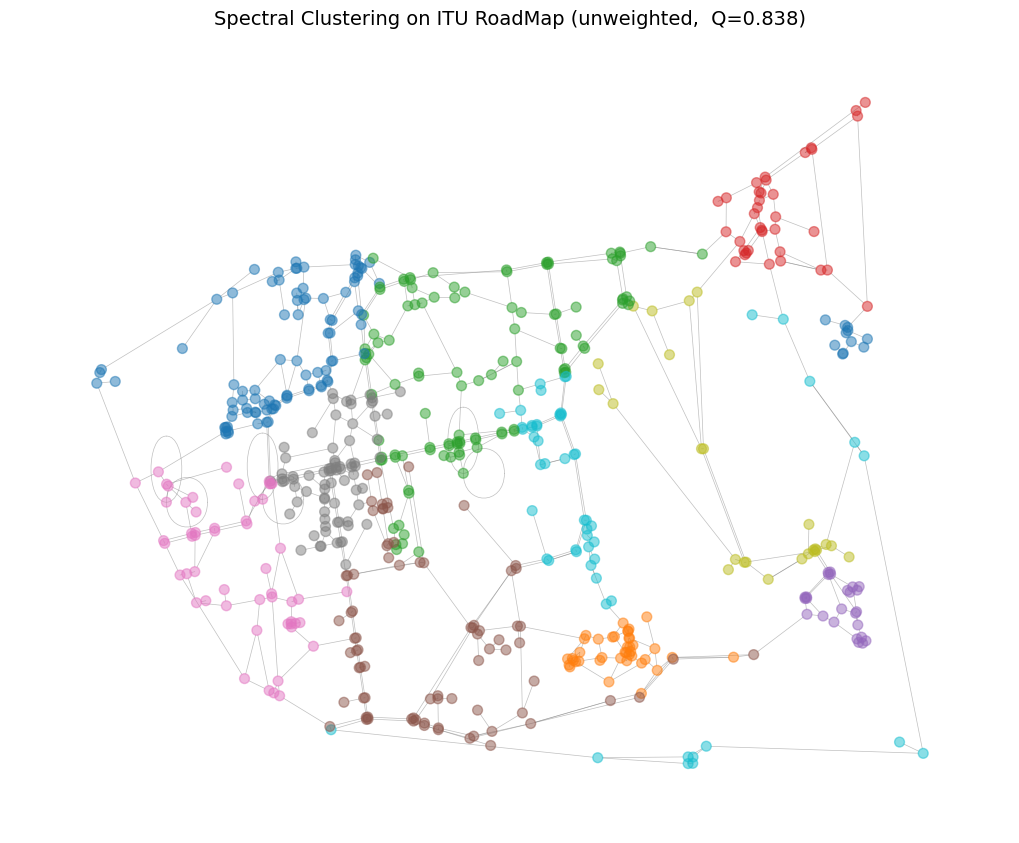

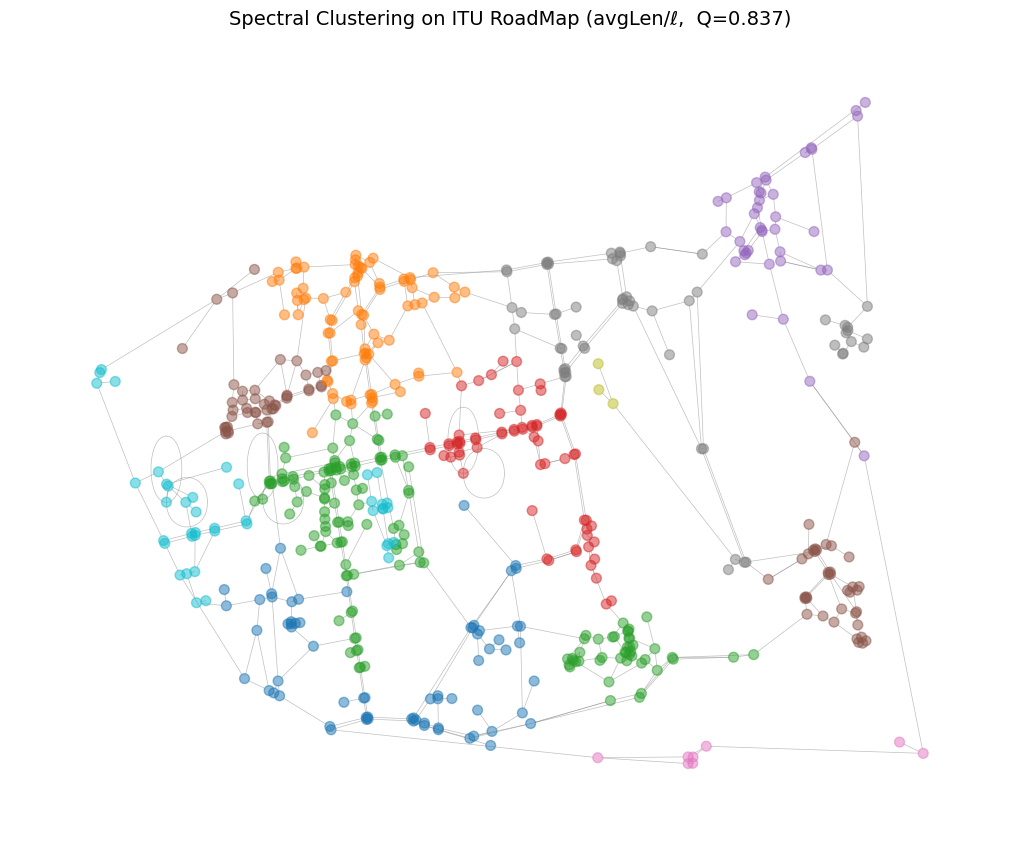

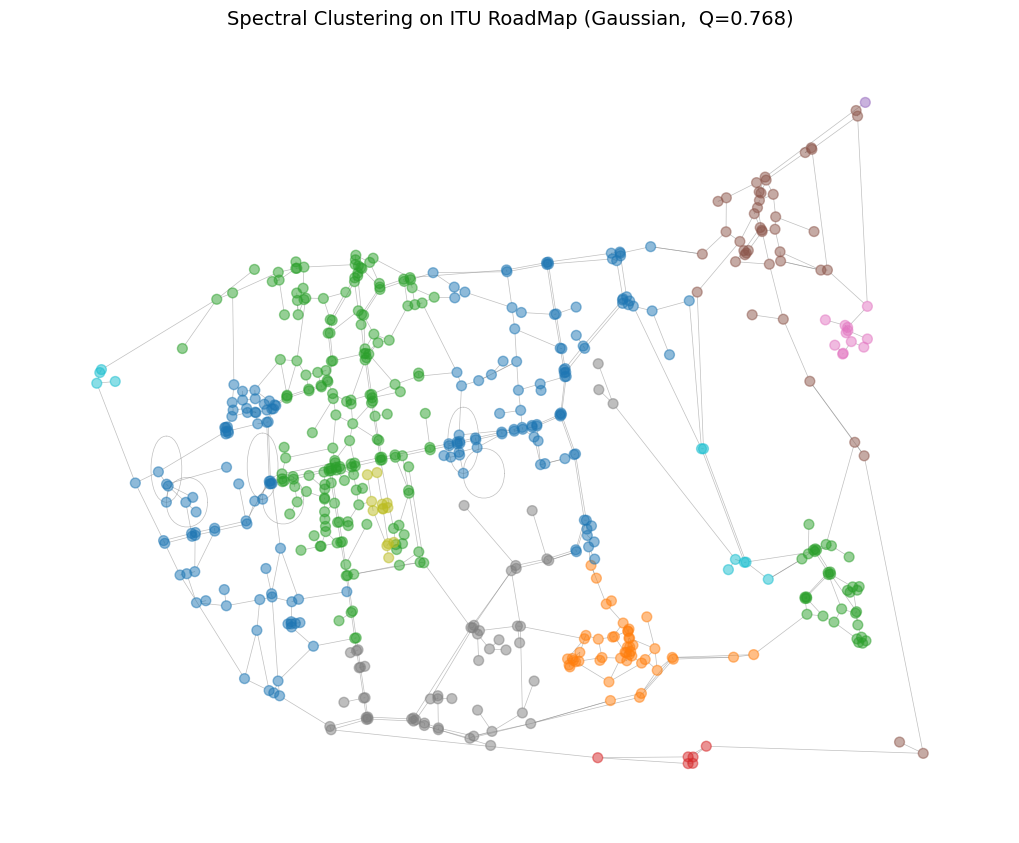

In [65]:
def show_clustered_graph(G, labels, title, cmap=plt.cm.tab10): #function to plot the graph

    xpos = nx.get_node_attributes(G, "x")       # longitude
    ypos = nx.get_node_attributes(G, "y")       # latitude
    len(xpos) == G.number_of_nodes() and len(ypos) == G.number_of_nodes()
    pos = {n: (xpos[n], ypos[n]) for n in G.nodes()}

    plt.figure(figsize=(10, 8))
    nx.draw(G, pos,
            node_color=labels,
            cmap=cmap,
            node_size=50,
            edge_color="gray",
            alpha=0.5,
            width=0.5)
    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()

# calls the plotter for every Laplacian we processed
for name,(lbl,Q) in results.items():
    show_clustered_graph(
        G,
        lbl,
        f"Spectral Clustering on ITU RoadMap ({name},  Q={Q:.3f})"
    )


c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\spectral\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Coordinate-based k-means modularity: 0.8067


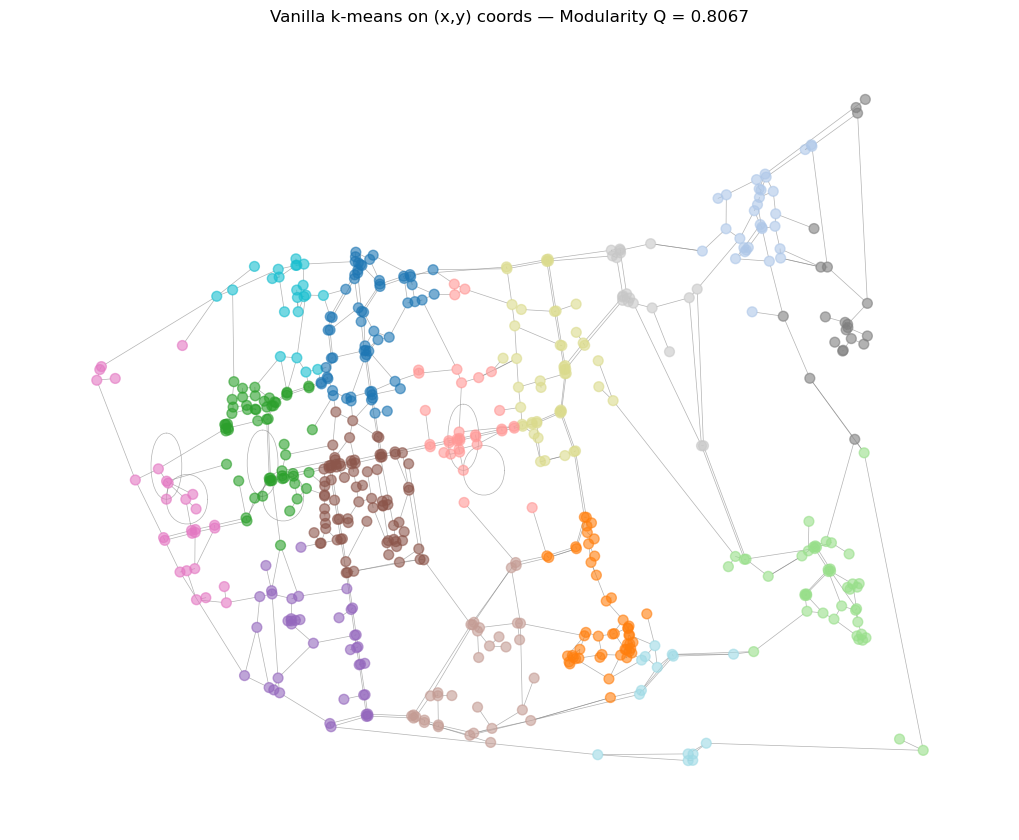

In [66]:
# 1) Build an (n×2) array of (x,y) for each node in the same order as A
nodes = list(G)
xpos = nx.get_node_attributes(G, "x")
ypos = nx.get_node_attributes(G, "y")
coords = np.array([(xpos[n], ypos[n]) for n in nodes])

# 2) Run k-means on these coordinates
km = KMeans(n_clusters=K_CLUSTERS, random_state=0)
coord_labels = km.fit_predict(coords)

# 3) Compute modularity Q for these labels
A = nx.to_numpy_array(G, nodelist=nodes)
def modularity(A, labels):
    m = A.sum() / 2
    k_vec = A.sum(axis=1)
    Q = 0.0
    for i in range(len(labels)):
        for j in range(len(labels)):
            if labels[i] == labels[j]:
                Q += A[i,j] - k_vec[i]*k_vec[j]/(2*m)
    return Q/(2*m)

Q_coord = modularity(A, coord_labels)
print(f"Coordinate-based k-means modularity: {Q_coord:.4f}")

# 4) Plot the graph colored by these coordinate-based clusters
pos = {n: (xpos[n], ypos[n]) for n in nodes}
plt.figure(figsize=(10,8))
nx.draw(
    G, pos,
    node_color=coord_labels,
    cmap=plt.cm.tab20,
    node_size=50,
    edge_color="gray",
    alpha=0.6,
    width=0.5
)
plt.title(f"Vanilla k-means on (x,y) coords — Modularity Q = {Q_coord:.4f}")
plt.axis("off")
plt.show()
